# TelCo Churn Prediction

**Bussiness problem**
* have to predict churn
* Churn is serious type of problem for a company becouse it in future directly going to affect company growth


In [7]:
import pandas as pd
import zipfile
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# zip_file_name = 'archive.zip'

# with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
#     zip_ref.extractall('.')
#     print(f"Successfully unzipped {zip_file_name}")



In [9]:
df = pd.read_csv("/content/Telco-Customer-Churn.csv")
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6294,6615-ZGEDR,Male,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.70,19.7,Yes
4107,2190-PHBHR,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,...,No,No,No,Yes,Two year,Yes,Credit card (automatic),94.45,6921.7,No
2976,4830-FAXFM,Male,0,No,Yes,19,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Credit card (automatic),24.10,439.2,No
5185,3021-VLNRJ,Female,0,No,Yes,50,Yes,No,DSL,Yes,...,Yes,Yes,Yes,No,One year,Yes,Credit card (automatic),70.80,3478.15,No
989,3280-NMUVX,Male,0,Yes,Yes,34,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),19.60,678.8,No


# 1. Understanding The Problem

In [10]:
# Deliverable:

# churn is basically clients or custmers leaving service/platform.

# Churn is primarily driven by contract type, tenure, service engagement, and pricing.

# we have to predict that how many possible clients going to leave our platform
# so stakeholders can do something for them so they may not leave
# total 7043 customers
# Churn 1869
# Nochurn 5174


# it is very important for bussiness to handle this type of situation becouse this
# this can effect directly on gross revenue if we dont have any idea or any number
# about our custumer that how many customers in future is possible that they can leave
# our service or maybe we can give some discount or some offers to keep intact




# Data Understanding

In [11]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


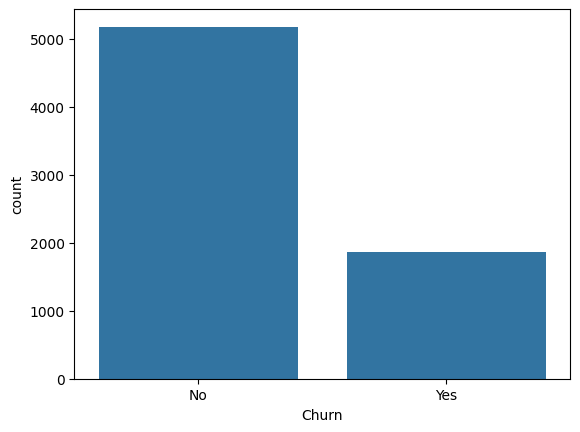

In [13]:
# Churn Distribution plot

sns.countplot(x='Churn', data=df)
plt.show()
# Sligthly imbalaced dataset with few churn cases

In [14]:
churn_percentage = df['Churn'].value_counts(normalize=True) * 100
print('Percentage of customers who churned and did not churn:')
print(churn_percentage)

Percentage of customers who churned and did not churn:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


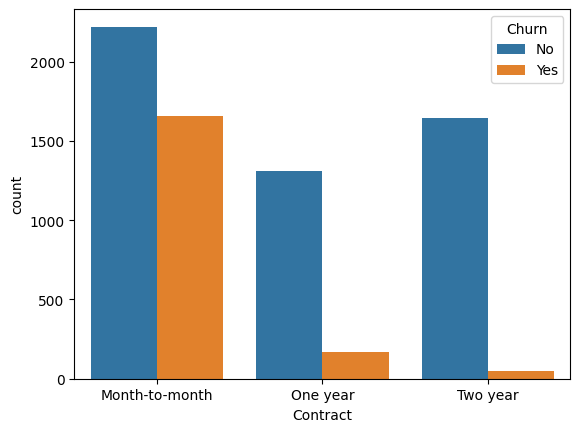

In [15]:
# Churn vs Contract
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()
#Customers on month-to-month contracts show significantly higher churn, indicating lack of long-term commitment.

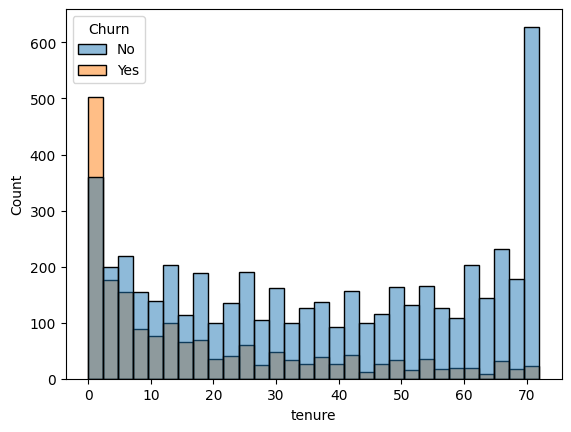

In [16]:
# Tenure vs Churn
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)
plt.show()

# Customers with low tenure are more likely to churn, which highlights the importance of early retention strategies.

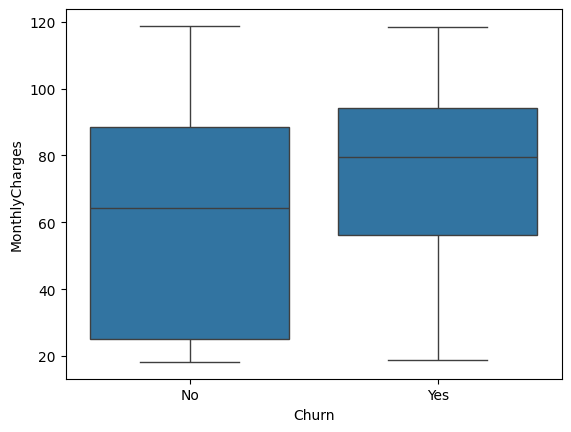

In [17]:
# Monthly Charges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

#“Higher monthly charges correlate with increased churn risk, suggesting pricing sensitivity.

# 2. Data Cleaning

In [18]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6031,0282-NVSJS,Female,1,Yes,Yes,12,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,Yes,Mailed check,29.30,355.9,No
5399,2589-AYCRP,Female,0,No,No,50,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),19.75,989.05,No
4653,2091-MJTFX,Female,0,Yes,Yes,30,No,No phone service,DSL,No,...,No,Yes,Yes,Yes,Month-to-month,No,Credit card (automatic),51.20,1561.5,Yes
5984,9185-TQCVP,Male,0,Yes,No,14,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.15,1139.2,Yes
3538,9028-LIHRP,Male,0,Yes,Yes,71,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),100.20,7209,No


In [21]:
df.info()  # have datatypes as object we want numaric

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [22]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [23]:
# droping customerID  coz no need in further pred for now
df.drop('customerID', axis=1, inplace=True)

df.sample(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5441,Female,0,Yes,No,70,Yes,Yes,DSL,Yes,No,Yes,Yes,No,No,Two year,No,Credit card (automatic),65.30,4759.75,Yes
6668,Female,0,No,No,38,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,103.65,3988.5,No
1200,Male,0,No,No,37,Yes,Yes,Fiber optic,No,Yes,No,Yes,Yes,Yes,One year,Yes,Credit card (automatic),104.50,3778,No


## Project workflow  





In [24]:
# 1. define the objective
  # churn

# 2. categorized columns
  # churn

  # gender
  # seniorCitizen
  # partner
  # dependents

  # tenure
  # contract
  # paperlessbilling
  # paymentmethod

  # PhoneService
  # MultipleLines
  # InternetService
  # OnlineSecurity
  # OnlineBackup
  # DeviceProtection
  # TechSupport
  # StreamingTV
  # StreamingMovies

  # MonthlyCharges
  # TotalCharges

# 3. have to remove low level or redundent cols
# phoneService  multipleLines
# internetservice  OnlineSecurity	OnlineBackup DeviceProtection	TechSupport	StreamingTV	StreamingMovies

# 4. Correlation / Signal Check
# Drop columns with near-zero relationship to churn

# 5. Feature Engineering
# Feature Engineering > Feature Deletion

# 6. Model building

# 7. Model Evaluation


In [25]:
# coverting datatypes and filling null with their mean

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)




/tmp/ipykernel_5452/993872654.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)


In [26]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [27]:
# Convert Target (Churn) → Numeric

df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [28]:
df['Churn'].isnull().sum()

np.int64(0)

In [29]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441,0.265370
std,0.368612,24.559481,30.090047,2265.000258,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,402.225000,0.000000
50%,0.000000,29.000000,70.350000,1400.550000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


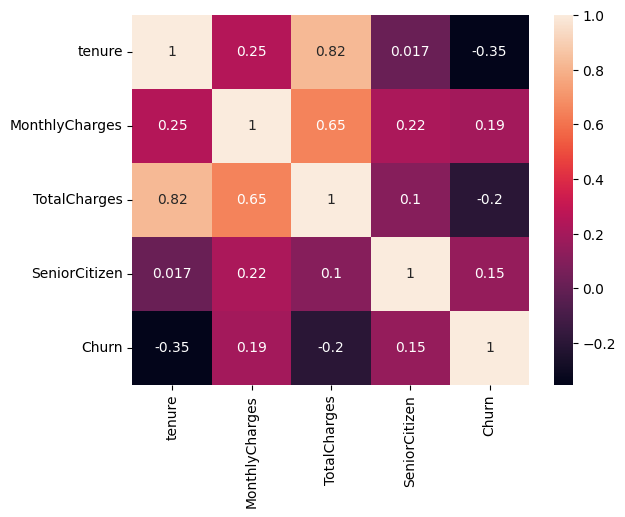

In [30]:
# Correlation (ONLY for numerical columns)

import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['tenure','MonthlyCharges','TotalCharges','SeniorCitizen']

corr = df[num_cols + ['Churn']].corr()
sns.heatmap(corr,annot=True)
plt.show()

In [31]:
# Categorical Feature Importance   chi squere test

from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

In [32]:
from sklearn.feature_selection import chi2

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

chi_scores = chi2(X, y)

chi_df = pd.DataFrame({
    'Feature': X.columns,
    'Chi2 Score': chi_scores[0],
    'p-value': chi_scores[1]
})

chi_df.sort_values(by='Chi2 Score', ascending=False, inplace=True)

print(chi_df)

             Feature     Chi2 Score        p-value
18      TotalCharges  629275.029414   0.000000e+00
4             tenure   16278.923685   0.000000e+00
17    MonthlyCharges    3680.787699   0.000000e+00
14          Contract    1115.780167  1.227941e-244
8     OnlineSecurity     551.611529  5.615882e-122
11       TechSupport     523.303866  8.086236e-116
9       OnlineBackup     230.086520   5.707869e-52
10  DeviceProtection     191.303140   1.651539e-43
1      SeniorCitizen     134.351545   4.576959e-31
3         Dependents     133.036443   8.876729e-31
15  PaperlessBilling     105.680863   8.661987e-25
2            Partner      82.412083   1.104764e-19
16     PaymentMethod      58.492250   2.040933e-14
7    InternetService       9.821028   1.725279e-03
6      MultipleLines       9.746921   1.796233e-03
13   StreamingMovies       8.235399   4.108113e-03
12       StreamingTV       7.490203   6.203556e-03
0             gender       0.258699   6.110156e-01
5       PhoneService       0.09

In [33]:
# keeping this cols
# TotalCharges
# tenure
# MonthlyCharges
# Contract

In [34]:
#  converting contract to numaric
df['Contract'] = df['Contract'].map({'Month-to-month':1, 'One year':2, 'Two year':3})



In [35]:
df['Contract'].value_counts()

,count
Contract,
1,3875
3,1695
2,1473


In [36]:
# Model importance: Using RandomForestClassifier for feature importance and arranged them in desc

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

TotalCharges        0.194530
MonthlyCharges      0.179677
tenure              0.149383
Contract            0.080844
PaymentMethod       0.050822
OnlineSecurity      0.046956
TechSupport         0.040072
InternetService     0.028761
gender              0.028101
OnlineBackup        0.027365
PaperlessBilling    0.025443
DeviceProtection    0.023851
Partner             0.022684
MultipleLines       0.022506
SeniorCitizen       0.020622
Dependents          0.019086
StreamingTV         0.017279
StreamingMovies     0.016899
PhoneService        0.005120
dtype: float64


In [37]:
# Correlation = basic filtering
# Chi-square = better
# Model importance = closest to real world


# 3. Exploratory data analysis EDA

In [38]:
# Are high charges customers churning more?
# Does contract type affect churn?
# Does tenure impact churn?

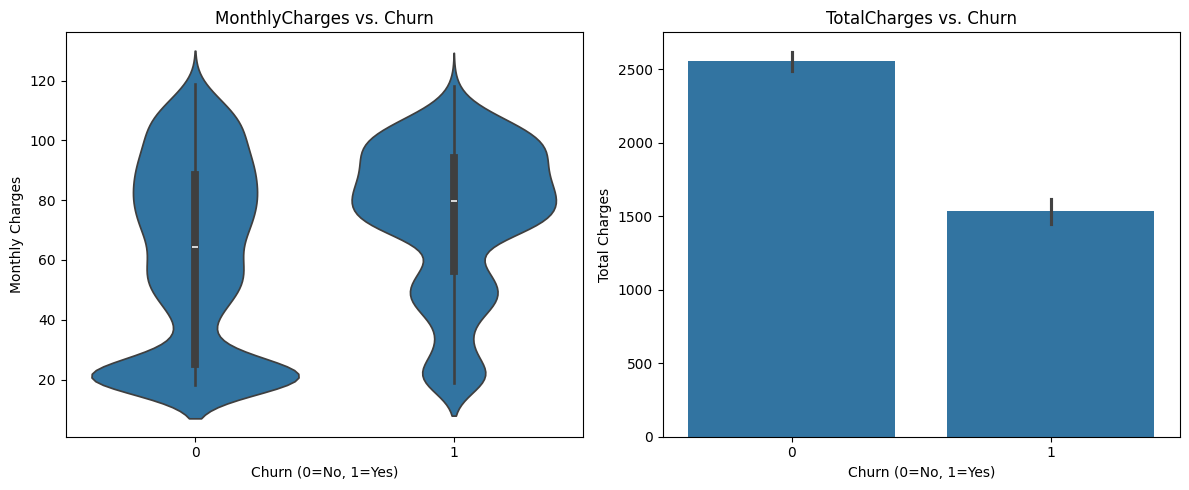

In [39]:
# Are high charges customers churning more?
# ploting charges and churn

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.violinplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('MonthlyCharges vs. Churn')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Monthly Charges')

plt.subplot(1, 2, 2)
sns.barplot(x='Churn', y='TotalCharges', data=df)
plt.title('TotalCharges vs. Churn')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Total Charges')

plt.tight_layout()
plt.show()


From these violin plots:

*   **MonthlyCharges vs. Churn:** We can observe that customers with higher monthly charges seem to have a higher density in the 'Yes' (churned) category, especially in the upper ranges. The distribution for churned customers appears to be shifted towards higher monthly charges compared to non-churned customers.

*   **TotalCharges vs. Churn:** For total charges, the density for 'No' (non-churned) customers is spread across the entire range, including very high total charges. In contrast, 'Yes' (churned) customers tend to have lower total charges, with a higher density concentrated at the lower end. This makes sense as churned customers might not have stayed long enough to accumulate high total charges.

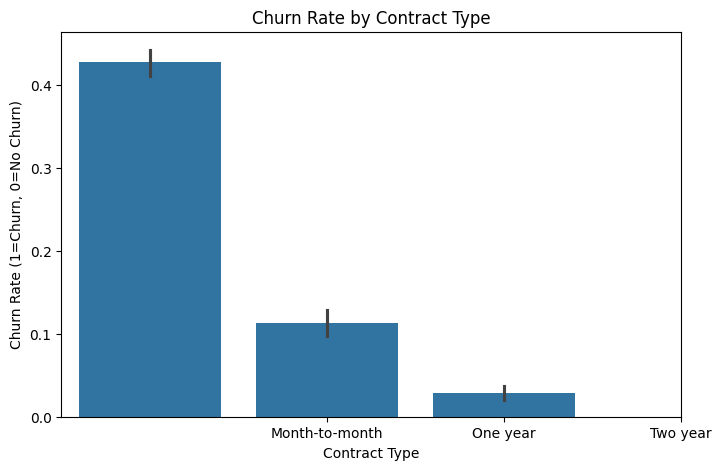

In [40]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Contract', y='Churn', data=df)
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (1=Churn, 0=No Churn)')
plt.xticks(ticks=[1, 2, 3], labels=['Month-to-month', 'One year', 'Two year'])
plt.show()

From this bar plot, we can observe:

*   **Month-to-month contracts (1)** have a significantly higher churn rate compared to longer-term contracts.
*   **One-year contracts (2)** have a lower churn rate than month-to-month.
*   **Two-year contracts (3)** have the lowest churn rate, suggesting that customers on longer contracts are much less likely to churn.

This highlights that contract type is a strong predictor of churn, with shorter, more flexible contracts being associated with higher churn.

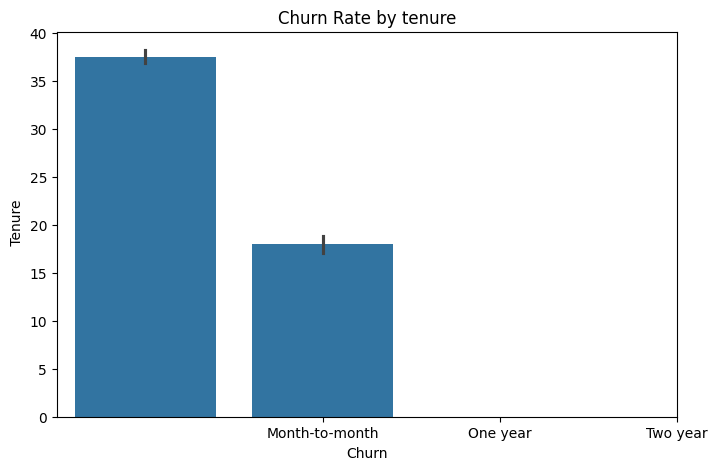

In [41]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Churn', y='tenure', data=df)
plt.title('Churn Rate by tenure')
plt.xlabel('Churn')
plt.ylabel(' Tenure')
plt.xticks(ticks=[1, 2, 3], labels=['Month-to-month', 'One year', 'Two year'])
plt.show()

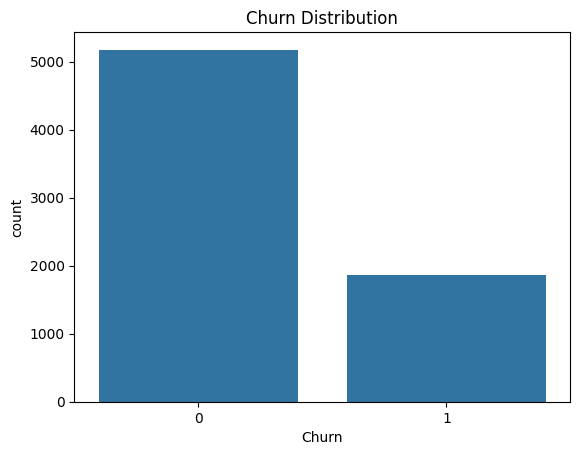

In [42]:
# A. Churn Problem Severity

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

Around X% of customers have churned, indicating a significant retention problem that requires proactive intervention.

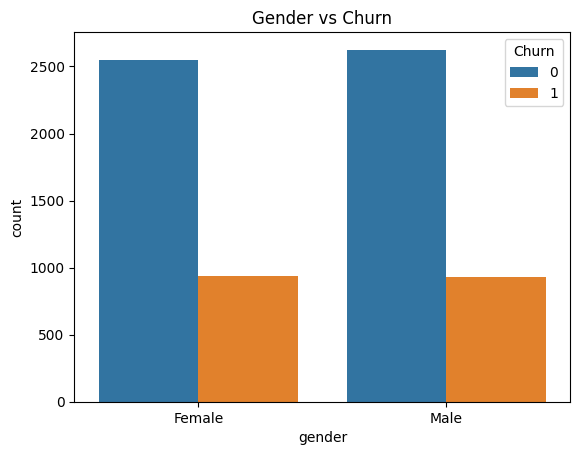

In [43]:
# B. Customer Demographics Impact
# Gender vs Churn
sns.countplot(x='gender', hue='Churn', data=df)
plt.title("Gender vs Churn")
plt.show()

Gender does not significantly impact churn — distribution is almost equal.

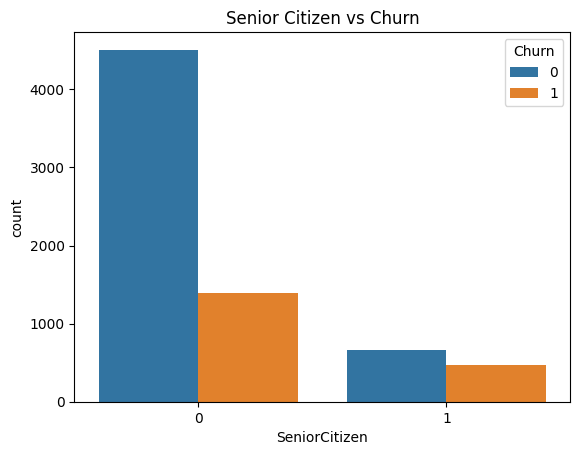

In [44]:
# Senior Citizen vs Churn
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title("Senior Citizen vs Churn")
plt.show()

Senior citizens show higher churn rates, possibly due to lower service satisfaction or pricing sensitivity.”

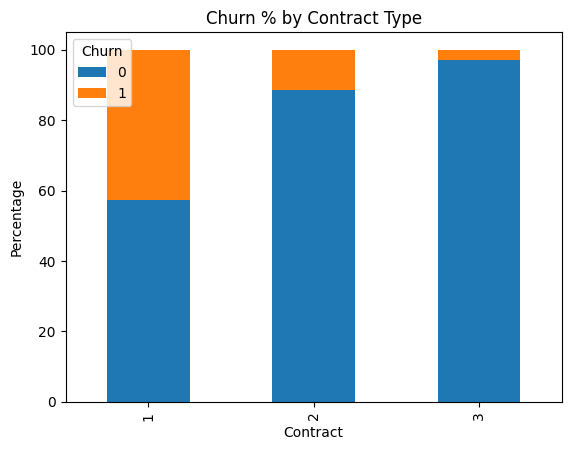

In [45]:
# C. Contract & Subscription Behavior
# Contract vs Churn (WITH % — important)
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=True)

plt.title("Churn % by Contract Type")
plt.ylabel("Percentage")
plt.show()

Month-to-month customers have significantly higher churn, while long-term contracts reduce churn risk.”

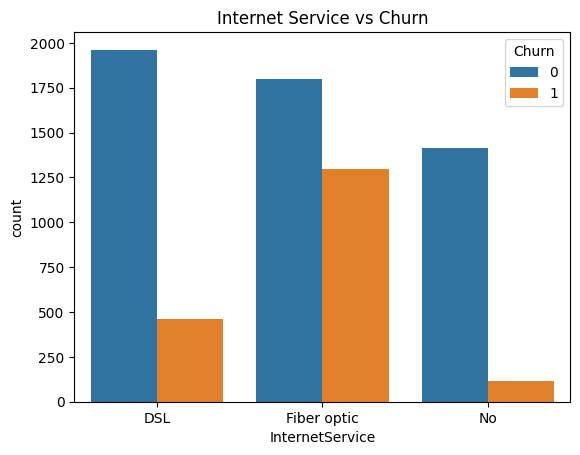

In [46]:
# Internet Service vs Churn
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Internet Service vs Churn")
plt.show()


Fiber optic users tend to churn more, possibly due to higher pricing.

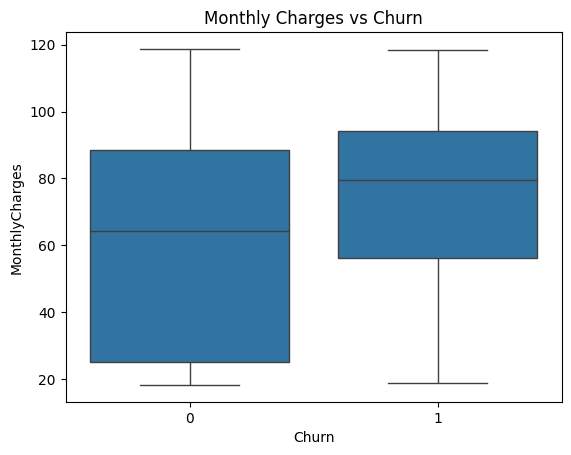

In [47]:
# Financial Behavior
# Monthly Charges
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

Customers with higher monthly charges are more likely to churn, indicating price dissatisfaction.”

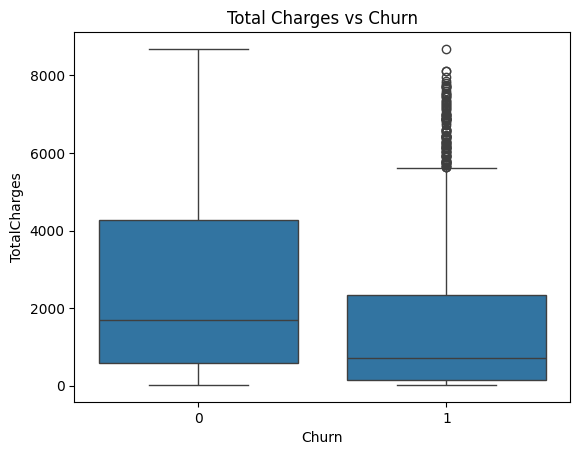

In [48]:
# Total Charges
sns.boxplot(x='Churn', y='TotalCharges', data=df)
plt.title("Total Charges vs Churn")
plt.show()

Lower total charges among churned users suggest they leave early in their lifecycle.

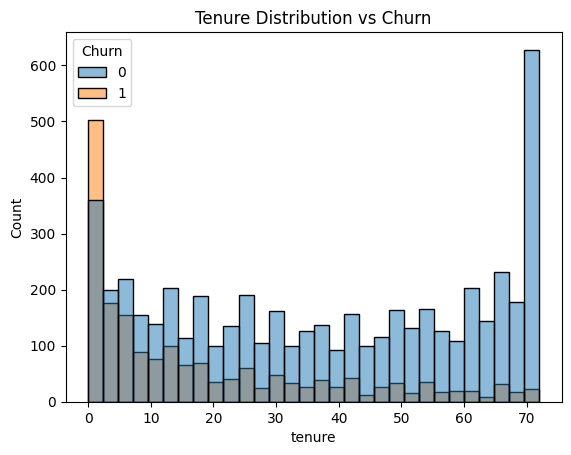

In [49]:
# Customer Loyalty
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)
plt.title("Tenure Distribution vs Churn")
plt.show()



Churn is concentrated among customers with low tenure, highlighting early-stage dissatisfaction.

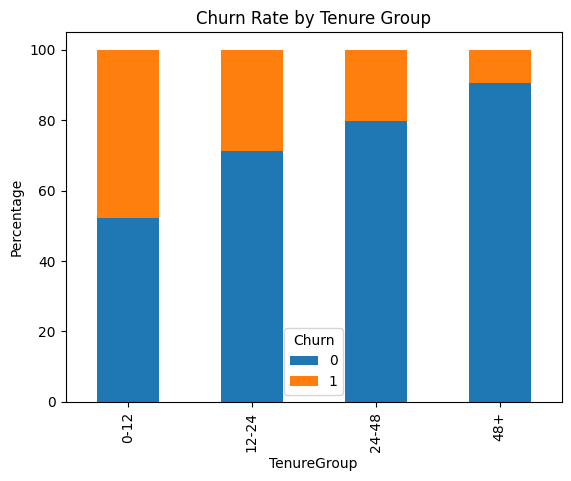

In [50]:
# Tenure Segmentation
# Create bins

df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,100],
    labels=['0-12','12-24','24-48','48+']
)
# Plot churn rate
tenure_churn = pd.crosstab(df['TenureGroup'], df['Churn'], normalize='index') * 100
tenure_churn.plot(kind='bar', stacked=True)

plt.title("Churn Rate by Tenure Group")
plt.ylabel("Percentage")
plt.show()

Churn is highest in the first 12 months, indicating onboarding and early engagement issues.

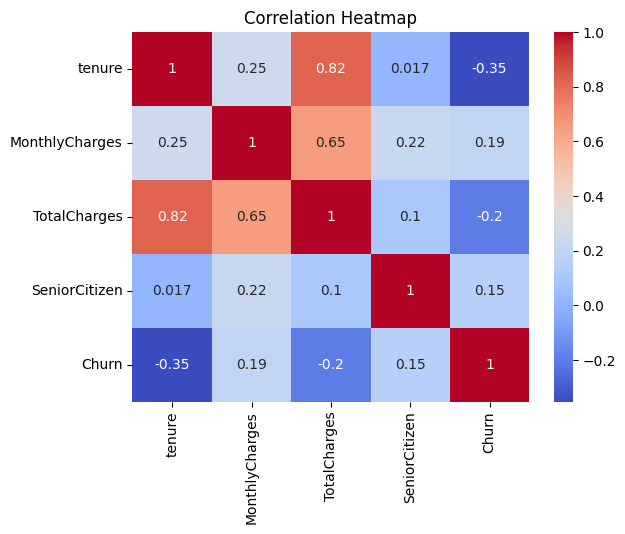

In [51]:
# Correlation Heatmap (Numerical Only)
num_cols = ['tenure','MonthlyCharges','TotalCharges','SeniorCitizen']

sns.heatmap(df[num_cols + ['Churn']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Tenure shows the strongest negative correlation with churn, while monthly charges have a moderate positive relationship.

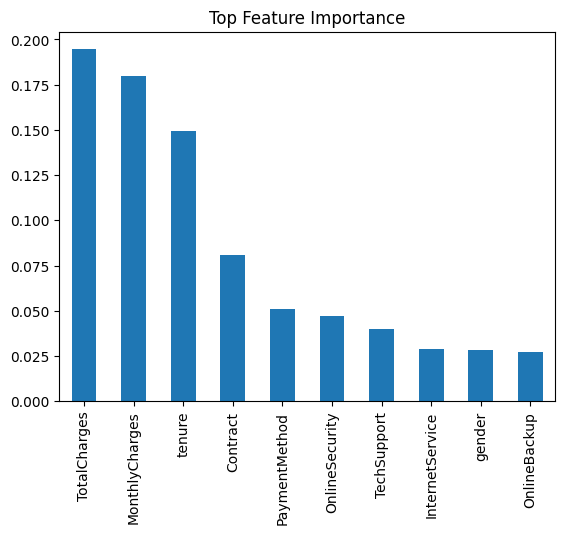

In [52]:
# Feature Importance (Model Output)
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top Feature Importance")
plt.show()


Key drivers of churn include tenure, contract type, and monthly charges, aligning with earlier EDA findings.

**Final Business Recommendations**



“Based on the analysis, the company should focus on reducing early-stage churn by improving onboarding experience, offering incentives for long-term contracts, and optimizing pricing strategies for high-paying customers. Additionally, increasing service engagement can improve customer retention.”

# 4. Feature Engineering

In [53]:
# Feature Engineering
# goal  “What kind of customer is likely to churn?”


# Why?
# Raw TotalCharges and tenure are weak individually. Together = powerful.
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)


# Insight:
# High spend + low tenure → risky customer

In [54]:
services = [
    'PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]

df['TotalServices'] = df[services].apply(lambda x: sum(x == 'Yes'), axis=1)

# Insight:
# More services = more stickiness = less churn



In [55]:
# Tenure Bucketing (Behavior Segmentation)

def tenure_group(x):
    if x <= 12:
        return 'New'
    elif x <= 36:
        return 'Mid-term'
    else:
        return 'Loyal'

df['TenureGroup'] = df['tenure'].apply(tenure_group)

# Insight:
# New customers churn more → this captures lifecycle stage


In [56]:
# Contract Risk Level
# Instead of raw categories → convert into risk signal

df['ContractRisk'] = df['Contract'].map({
    'Month-to-month': 2,
    'One year': 1,
    'Two year': 0
})

In [57]:
df['PaymentRisk'] = df['PaymentMethod'].apply(
    lambda x: 1 if 'electronic check' in x.lower() else 0
)

In [58]:
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes':1, 'No':0})

df['HighCharges'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)
# Insight:
# Expensive plans → churn trigger

In [59]:
df['IsSenior'] = df['SeniorCitizen']

In [60]:
# Service Dependency Fix
df['HasInternet'] = (df['InternetService'] != 'No').astype(int)

I engineered behavioral, financial, and service-based features such as customer engagement (TotalServices), lifecycle segmentation (TenureGroup), and revenue efficiency (AvgMonthlySpend) to improve predictive performance.

In [61]:
# dataset
# Keep:
# tenure
# MonthlyCharges
# TotalCharges

# Add:
# AvgMonthlySpend
# TotalServices
# TenureGroup
# ContractRisk
# PaymentRisk
# HighCharges
# HasInternet

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


In [63]:
# Drop Unnecessary Columns
drop_cols = [
    'gender',                 # weak signal
    'PhoneService',           # redundant
    'MultipleLines',          # dependent
    'InternetService',        # replaced by HasInternet
    'TotalCharges'            # replaced by AvgMonthlySpend
]

df.drop(columns=drop_cols, inplace=True)


# Why?
# These either add noise, redundancy, or are already captured in engineered features

In [64]:
# encoding
df = pd.get_dummies(df, drop_first=True)

In [65]:
df.sample(5)

,SeniorCitizen,tenure,Contract,PaperlessBilling,MonthlyCharges,Churn,AvgMonthlySpend,TotalServices,ContractRisk,PaymentRisk,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_Mid-term,TenureGroup_New
597,0,4,1,0,65.55,0,47.440000,4,NaN,0,...,True,False,False,False,True,False,False,True,False,True
1362,0,4,1,1,70.20,1,47.590000,1,NaN,1,...,False,False,False,False,False,False,True,False,False,True
602,0,66,2,1,74.25,0,72.526119,2,NaN,0,...,False,False,False,False,False,False,False,False,False,False
2156,0,2,1,0,80.55,1,61.366667,2,NaN,1,...,False,False,False,False,True,False,True,False,False,True
3158,0,18,1,1,49.55,1,46.228947,2,NaN,0,...,False,False,False,False,False,False,False,True,True,False


In [66]:
# deleting ContractRisk coz contains nan values
df.drop('ContractRisk', axis=1, inplace=True)

In [67]:
# spliting features

X = df.drop('Churn', axis=1)
y = df['Churn']

In [68]:
X.sample(5)

,SeniorCitizen,tenure,Contract,PaperlessBilling,MonthlyCharges,AvgMonthlySpend,TotalServices,PaymentRisk,HighCharges,IsSenior,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_Mid-term,TenureGroup_New
2044,0,7,2,0,19.50,16.075000,1,0,0,0,...,False,True,False,True,False,False,False,True,False,True
3111,0,72,3,1,103.40,100.995205,6,1,1,0,...,False,False,True,False,True,False,True,False,False,False
5500,0,60,3,0,60.50,60.564754,4,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4881,0,28,1,0,76.55,71.220690,2,0,1,0,...,True,False,False,False,False,False,False,False,True,False
5504,1,44,2,0,88.40,86.953333,4,0,1,1,...,False,False,False,False,True,False,False,True,False,False


In [69]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   Contract                               7043 non-null   int64  
 3   PaperlessBilling                       7043 non-null   int64  
 4   MonthlyCharges                         7043 non-null   float64
 5   AvgMonthlySpend                        7043 non-null   float64
 6   TotalServices                          7043 non-null   int64  
 7   PaymentRisk                            7043 non-null   int64  
 8   HighCharges                            7043 non-null   int64  
 9   IsSenior                               7043 non-null   int64  
 10  HasInternet                            7043 non-null   int64  
 11  Part

# 5. Model Building


In [70]:
# Train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [71]:
# Model 1: Logistic Regression (baseline)
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [72]:
# model 2: Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)


DecisionTreeClassifier()

In [73]:
# Model 3: Random Forest (strong baseline)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# 6. Evaluation

In [74]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_lr = lr.predict(X_test)

print("Accuracy LR:", accuracy_score(y_test, y_pred_lr))
print("LR:", confusion_matrix(y_test, y_pred_lr))
print("LR:",classification_report(y_test, y_pred_lr))



Accuracy LR: 0.7998580553584103
LR: [[933 103]
 [179 194]]
LR:               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.65      0.52      0.58       373

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [75]:
y_pred_dt = dt.predict(X_test)

print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(accuracy_score(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1036
           1       0.48      0.47      0.48       373

    accuracy                           0.73      1409
   macro avg       0.65      0.64      0.65      1409
weighted avg       0.72      0.73      0.73      1409

[[850 186]
 [198 175]]
0.7274662881476224


In [76]:
y_pred_rf = rf.predict(X_test)

print("Accuracy RF:", accuracy_score(y_test, y_pred_rf))
print("RF:", confusion_matrix(y_test, y_pred_rf))
print("RF:", classification_report(y_test, y_pred_rf))

Accuracy RF: 0.7899219304471257
RF: [[930 106]
 [190 183]]
RF:               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1036
           1       0.63      0.49      0.55       373

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



# Model Improvement

In [77]:
# A. Hyperparameter Tuning (Random Forest)
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=3, scoring='f1')
grid.fit(X_train, y_train)

print(grid.best_params_)


{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [85]:
# B. XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:09:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1036
           1       0.63      0.54      0.58       373

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



In [82]:
# C. Handle Class Imbalance
from sklearn.utils import resample

# Combine X and y
train = pd.concat([X_train, y_train], axis=1)

# Separate classes
churn = train[train.Churn == 1]
not_churn = train[train.Churn == 0]

# Upsample minority
churn_upsampled = resample(churn, replace=True, n_samples=len(not_churn))

train_balanced = pd.concat([not_churn, churn_upsampled])

X_train_bal = train_balanced.drop('Churn', axis=1)
y_train_bal = train_balanced['Churn']


In [83]:
# D. ROC-AUC Score (Pro Move)
from sklearn.metrics import roc_auc_score

probs = rf.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, probs))

ROC-AUC: 0.8307278458082747


In [86]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

print("XGBoost")
print(classification_report(y_test, y_pred_xgb))

Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.65      0.52      0.58       373

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1036
           1       0.63      0.49      0.55       373

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

XGBoost
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1036
           1       0.63      0.54      0.58       373

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.7

In [88]:
# Exporting Random forest model selected random forest due to good performance overall

import joblib

joblib.dump(rf, "telco_churn_RFmodel.pkl")

['telco_churn_RFmodel.pkl']

In [90]:
joblib.dump(X.columns, "features.pkl")

['features.pkl']